# **PREDIKSI REVENUE FILM MENGGUNAKAN ALGORITMA RANDOM FOREST**

**Anggota Kelompok 9**

Ananda Keissa Az Zahra (24031554051)

Laili Nurrohmatul Fadhila Z. (24031554093)

Eka Putri Maharani (24031554121)

In [ ]:
!gdown --folder "https://drive.google.com/drive/folders/1i3CcLo-IHhdIwm2mwxSJEw7q429R4xsz?usp=sharing"

Retrieving folder contents
Processing file 1nQ7oTsHmZ7ozAtSQkfr2jIJmSI9RhHZw rotten_tomatoes_critic_reviews.csv
Processing file 1H-A5mqNcNcTIkSnOvG1-N_IRYzdxUzIG rotten_tomatoes_movies.csv
Processing file 1PETkOe6GEOVH97WB62NZTee1CWUeAqQS tmdb_5000_movies.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1nQ7oTsHmZ7ozAtSQkfr2jIJmSI9RhHZw
From (redirected): https://drive.google.com/uc?id=1nQ7oTsHmZ7ozAtSQkfr2jIJmSI9RhHZw&confirm=t&uuid=6ae91447-a362-4ee6-9b7e-bbf8ef6c172b
To: /content/dataset-pemteks/rotten_tomatoes_critic_reviews.csv
100% 226M/226M [00:02<00:00, 83.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1H-A5mqNcNcTIkSnOvG1-N_IRYzdxUzIG
To: /content/dataset-pemteks/rotten_tomatoes_movies.csv
100% 17.1M/17.1M [00:00<00:00, 41.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PETkOe6GEOVH97WB62NZTee1CWUeAqQS
To: /content/dataset-pemteks/t

## **Persiapan Data**

In [ ]:
import pandas as pd

# read file
movies = pd.read_csv('/content/dataset-pemteks/rotten_tomatoes_movies.csv')
review = pd.read_csv('/content/dataset-pemteks/rotten_tomatoes_critic_reviews.csv')
revenue = pd.read_csv('/content/dataset-pemteks/tmdb_5000_movies.csv')

# rename
revenue.rename(columns={'title': 'movie_title'}, inplace=True)

# subset
selected_movies = movies[['rotten_tomatoes_link', 'movie_title', 'content_rating', 'genres', 'directors', 'authors', 'actors',
                          'original_release_date', 'runtime', 'production_company']]
selected_review = review[['rotten_tomatoes_link', 'review_content', 'review_type']]
selected_revenue = revenue[['movie_title', 'revenue', 'popularity', 'budget', 'vote_count', 'vote_average']]

# merge
df1 = pd.merge(selected_movies, selected_review, on='rotten_tomatoes_link')
df = pd.merge(df1, selected_revenue, on='movie_title')

In [ ]:
review_counts = df.groupby('movie_title').size().reset_index(name='jumlah_review')

film_layak = review_counts[review_counts['jumlah_review'] >= 30]['movie_title']
df_filtered = df[df['movie_title'].isin(film_layak)].copy()

df_30 = df_filtered.groupby('movie_title').head(30)

final_counts = pd.crosstab(df_30['movie_title'], df_30['review_type'])

if 'Fresh' not in final_counts.columns: final_counts['Fresh'] = 0
if 'Rotten' not in final_counts.columns: final_counts['Rotten'] = 0

final_counts['total_reviews_scraped'] = final_counts['Fresh'] + final_counts['Rotten']

def hitung_ratio(row):
    total = row['total_reviews_scraped']
    if total == 0:
        return 0
    return row['Fresh'] / total

final_counts['freshness_ratio'] = final_counts.apply(hitung_ratio, axis=1)

In [ ]:
# ambil 30 review saja

review_counts = df.groupby('rotten_tomatoes_link').size().reset_index(name='review_content_count')
filtered_links = review_counts[review_counts['review_content_count'] >= 30]['rotten_tomatoes_link']
df = df[df['rotten_tomatoes_link'].isin(filtered_links)]
df = df.groupby('rotten_tomatoes_link').head(30)

In [ ]:
review_counts = df.groupby('rotten_tomatoes_link').size().reset_index(name='review_content_count')
print(review_counts)

           rotten_tomatoes_link  review_content_count
0                     m/0814255                    30
1                     m/0878835                    30
2          m/10002516-lost_city                    30
3           m/10003276-criminal                    30
4     m/10004288-running_scared                    30
...                         ...                   ...
3509               m/zombieland                    30
3510                m/zookeeper                    30
3511                m/zoolander                    30
3512              m/zoolander_2                    30
3513                m/zoom_2006                    30

[3514 rows x 2 columns]


In [ ]:
# gabung review_content berdasarkan kolom 'rotten_tomatoes_link'

df_aggregated = df.groupby('rotten_tomatoes_link')['review_content'].apply(lambda x: '. '.join(x.dropna())).reset_index()
df = df.drop(columns=['review_content'])
df = pd.merge(df, df_aggregated, on='rotten_tomatoes_link', how='left')
df = df.drop_duplicates(subset=['rotten_tomatoes_link'])

In [ ]:
df = pd.merge(df, final_counts, on='movie_title')

In [ ]:
df_final = df.drop(columns=['rotten_tomatoes_link'])
df_final.to_csv('df_final.csv', index=False)

In [ ]:
df_final['review_content']

,review_content
0,A fantasy adventure that fuses Greek mythology...
1,"Like Holofcener's previous pictures, Please Gi..."
2,Despite the strong emotional connection many M...
3,We got two and a half more months of crap to g...
4,An unapologetic in-your-face thriller that's s...
...,...
3509,A killer comedy with a vicious sense of humor....
3510,Zookeeper is essentially a surreally awful Hap...
3511,Making a movie that's stupid fun must be reall...
3512,"Like its predecessor, the best bits of this se..."


## **Preprocessing**

In [ ]:
import numpy as np

df = pd.read_csv('df_final.csv')

def parse(text):
  if pd.isna(text): return []
  return [x.strip() for x in str(text).split(',')]

cols_to_split = ['genres', 'authors', 'actors', 'directors']

for col in cols_to_split:
    df[col] = df[col].apply(parse)

In [ ]:
# tambah kolom (untuk fitur)
df['original_release_date'] = pd.to_datetime(df['original_release_date'])

df['release_year'] = df['original_release_date'].dt.year.astype('Int64')
df['release_month'] = df['original_release_date'].dt.month.astype('Int64')

df['num_actors'] = df['actors'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['num_genres'] = df['genres'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['num_authors'] = df['authors'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['num_directors'] = df['directors'].apply(lambda x: len(x) if isinstance(x, list) else 0)

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))
manual_stopwords = {
    "movie", "film", "movies", "films",
    "scene", "scenes", "character", "characters",
    "story", "plot", "really", "very", "much", "well", "quite", "just",
    "even", "still", "also", "though", "rather",
    "little", "lot", "thing", "things", "something",
    "anything", "everything", "nothing",
    "one", "two", "three", "many", "few",
    "bit", "kind", "sort", "type",
    "someone", "anyone", "everyone", "people",
    "fun", "good", "great", "nice", "bad",
    "better", "worst", "cool",
    "interesting",
    "get", "got", "give", "take",
    "make", "made", "makes",
    "seems", "seem", "seemed",
    "something", "anything", "everything", "nothing",
    "hollywood", "disney", "cast", "acting",
    "actor", "actors", "actress", "performance",
    "time", "minute", "way", "part", "end", "start",
    "they", "them", "their", "theirs",
    "he", "him", "his",
    "she", "her", "hers",
    "we", "us", "our", "ours",
    "you", "your", "yours",
    "feel", "felt", "feels",
    "look", "looks", "looked",
    "try", "tries", "tried",
    'could', 'may', 'might', 'would', 'will', 'can',
    'ever', 'never', 'always', 'first', 'last', 'new', 'old', 'year', 'time', 'moment',
    'big', 'high', 'low', 'long', 'short', 'real', 'fake',
    'come', 'go', 'going', 'turn', 'without', 'with', 'work', 'working',
    'see', 'watch', 'watching', 'seen', 'look', 'looking',
    'director', 'direct', 'filmmaker', 'screen', 'script', 'cast', 'actor', 'actress',
    'performance', 'played', 'play', 'star', 'audience', 'people', 'many', 'much',
    'like', 'really', 'well', 'good', 'bad', 'great', 'best', 'better',
    'another', 'every', 'find', 'man', 'picture', 'set', 'want',
    'direct', 'enough', 'hard', 'life', 'tale', 'coming', 'getting'
}
stop_words.update(manual_stopwords)
stemmer = SnowballStemmer("english")

def clean_text(row):
    text = str(row['review_content'])
    title = str(row['movie_title']).lower()

    if pd.isna(text): return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Hapus Judul Film didalam review
    title_clean = re.sub(r'[^a-z\s]', ' ', title)
    title_words = set([w for w in title_clean.split() if len(w) > 3])

    # 3. Hapus Angka & Tanda Baca
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 4. Tokenisasi
    words = text.split()

    clean_words = []
    for w in words:
        # Hapus Judul
        if w in title_words: continue

        # Hapus Stopwords
        if w not in stop_words and len(w) > 2:
            stem = stemmer.stem(w)
            clean_words.append(stem)

    return " ".join(clean_words)

df['review_clean_stemmed'] = df.apply(clean_text, axis=1)

In [ ]:
df['review_clean_stemmed']

,review_clean_stemmed
0,fantasi adventur fuse greek mytholog contempor...
1,holofcen previous pictur deriv narrat energi l...
2,despit strong emot connect miamian toward fall...
3,half month crap holiday award season produc so...
4,unapologet face thriller sure expect typic pau...
...,...
3509,killer comedi vicious sens humor run undead fa...
3510,essenti surreal aw happi madison product versi...
3511,make stupid must sinc filmmak mere stupid rare...
3512,predecessor bit sequel isol moment easi target...


## **EDA**

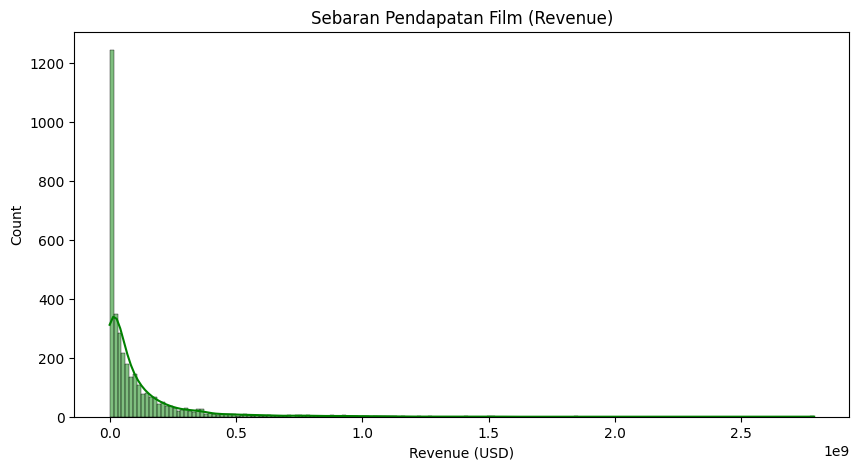

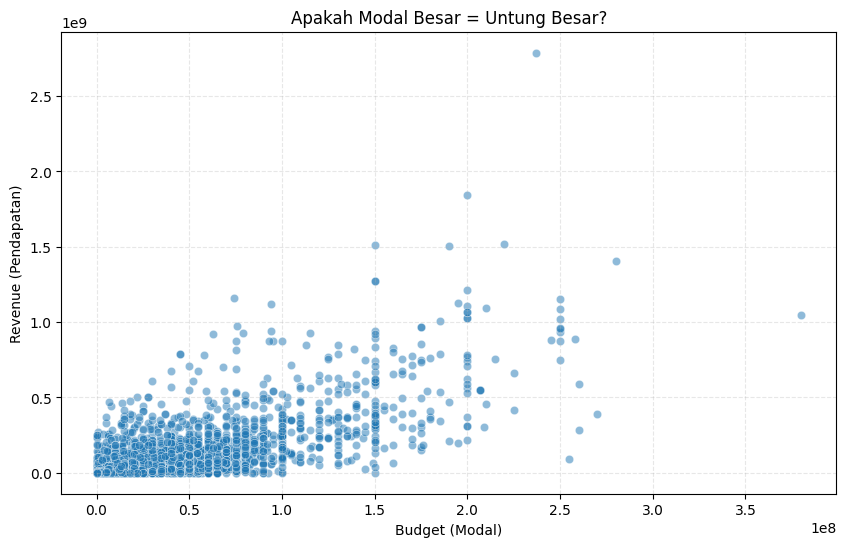

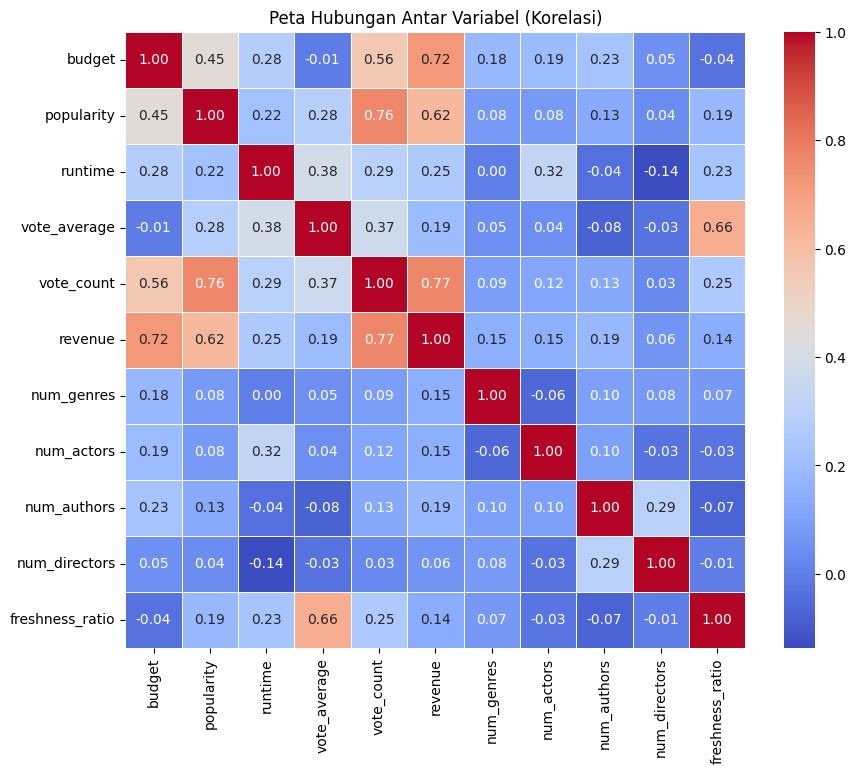

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribusi Revenue
plt.figure(figsize=(10, 5))
sns.histplot(df['revenue'], kde=True, color='green')
plt.title('Sebaran Pendapatan Film (Revenue)')
plt.xlabel('Revenue (USD)')
plt.show()

# Hubungan Budget dan Revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(x='budget', y='revenue', data=df, alpha=0.5)
plt.title('Apakah Modal Besar = Untung Besar?')
plt.xlabel('Budget (Modal)')
plt.ylabel('Revenue (Pendapatan)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Heatmap
cols_to_check = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'revenue', 'num_genres', 'num_actors', 'num_authors', 'num_directors', 'freshness_ratio']
corr_matrix = df[cols_to_check].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Peta Hubungan Antar Variabel (Korelasi)')
plt.show()

## **Feature Engineering**

### **TF-IDF dan PCA**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import pandas as pd

tfidf = TfidfVectorizer(max_features=1000, min_df=3)
tfidf_matrix = tfidf.fit_transform(df['review_clean_stemmed'])

# n = topic
n_components = 10
pca = PCA(n_components=n_components)
pca_matrix = pca.fit_transform(tfidf_matrix.toarray())

# membuat nama kolom topic 1 - 10
pca_cols = [f"Text_Topic_{i+1}" for i in range(n_components)]
df_pca = pd.DataFrame(pca_matrix, columns=pca_cols)

df.reset_index(drop=True, inplace=True)
df_pca.reset_index(drop=True, inplace=True)
tfidf_df = pd.concat([df, df_pca], axis=1)
tfidf_df = tfidf_df.drop(columns=['review_clean_stemmed', 'review'], errors='ignore')

In [ ]:
import pandas as pd

print("ISI TOPIK PCA")

vocab = tfidf.get_feature_names_out()

for i in range(n_components):
    topic = pca.components_[i]
    top_word_indices = topic.argsort()[-10:][::-1]
    top_words = [vocab[idx] for idx in top_word_indices]

    print(f"\nTopik {i+1} berisi tentang: {', '.join(top_words)}")

ISI TOPIK PCA

Topik 1 berisi tentang: comedi, funni, laugh, joke, romant, humor, gag, charm, comic, hilari

Topik 2 berisi tentang: horror, thriller, comedi, scare, scari, laugh, genr, funni, suspens, action

Topik 3 berisi tentang: anim, action, kid, sequel, horror, adventur, origin, franchis, children, pixar

Topik 4 berisi tentang: horror, anim, scare, scari, music, famili, kid, creepi, classic, haunt

Topik 5 berisi tentang: thriller, anim, suspens, comedi, twist, kid, polit, crime, famili, pixar

Topik 6 berisi tentang: romant, music, love, romanc, teen, charm, girl, predict, action, clich

Topik 7 berisi tentang: music, thriller, bond, danc, song, rock, number, western, biopic, scorses

Topik 8 berisi tentang: bond, romant, western, moor, jame, horror, anim, comedi, spi, action

Topik 9 berisi tentang: music, anim, romant, comedi, action, sci, epic, visual, western, classic

Topik 10 berisi tentang: action, war, famili, horror, kid, sport, drama, clich, fight, teen


In [ ]:
# memberi nama topik
nama_topik_baru = {
    'Text_Topic_1':  'Topic_Comedy_Humor',
    'Text_Topic_2':  'Topic_Horror_Thriller',
    'Text_Topic_3':  'Topic_Animation_Adventure',
    'Text_Topic_4':  'Topic_Classic_Creepy',
    'Text_Topic_5':  'Topic_Suspense_Crime',
    'Text_Topic_6':  'Topic_Romance_Teen',
    'Text_Topic_7':  'Topic_Music_Biopic',
    'Text_Topic_8':  'Topic_Spy_Action',
    'Text_Topic_9':  'Topic_Franchise_Sequel',
    'Text_Topic_10': 'Topic_Action_War'
}

tfidf_df = tfidf_df.rename(columns=nama_topik_baru)
tfidf_df = tfidf_df.filter(like='Topic_')

### **One Hot Encoding**

In [ ]:
from collections import Counter
import calendar

# genre
all_genres = [g for sublist in df['genres'] for g in sublist]
top_genres = [g for g, c in Counter(all_genres).most_common(20)]

for g in top_genres:
    col_name = f'Genre_{g.replace(" ", "_")}'
    df[col_name] = df['genres'].apply(lambda x: 1 if g in x else 0)

# actor
all_cast = [c for sublist in df['actors'] for c in sublist]
top_cast = [c for c, count in Counter(all_cast).most_common(20)]

for c in top_cast:
    safe_name = c.replace(" ", "_")
    df[f'Actor_{safe_name}'] = df['actors'].apply(lambda x: 1 if c in x else 0)

# rating
df['content_rating'] = df['content_rating'].fillna('Unrated')

df = pd.get_dummies(df, columns=['content_rating'], prefix='Rating', dtype=int)

# company
top_companies = df['production_company'].value_counts().head(20).index.tolist()

for comp in top_companies:
    safe_name = str(comp).replace(" ", "_").replace(".", "")
    df[f'Studio_{safe_name}'] = df['production_company'].apply(lambda x: 1 if comp in str(x) else 0)

# month
df['month_name'] = df['release_month'].apply(lambda x: calendar.month_abbr[int(x)] if pd.notna(x) else 'Unknown')
df = pd.get_dummies(df, columns=['month_name'], prefix='Month', dtype=int)

# authors
all_authors = [a for sublist in df['authors'] for a in sublist]
top_authors = [a for a, c in Counter(all_authors).most_common(20)]

for a in top_authors:
    safe_name = a.replace(" ", "_")
    df[f'Author_{safe_name}'] = df['authors'].apply(lambda x: 1 if a in x else 0)

In [ ]:
cols_to_drop_base = ['genres', 'content_rating', 'directors', 'authors',
                     'actors', 'original_release_date',	'production_company',
                     'review_content', 'review_clean_stemmed', 'month_name', 'release_month',
                     'release_year', 'review_type', 'Fresh', 'Rotten', 'total_reviews_scraped']
df_final = df.drop(columns=cols_to_drop_base, errors='ignore')

In [ ]:
df = pd.concat([df_final, tfidf_df], axis=1)

In [ ]:
df

,movie_title,runtime,revenue,popularity,budget,vote_count,vote_average,freshness_ratio,num_actors,num_genres,...,Topic_Comedy_Humor,Topic_Horror_Thriller,Topic_Animation_Adventure,Topic_Classic_Creepy,Topic_Suspense_Crime,Topic_Romance_Teen,Topic_Music_Biopic,Topic_Spy_Action,Topic_Franchise_Sequel,Topic_Action_War
0,Percy Jackson & the Olympians: The Lightning T...,119.0,226497209,61.121717,95000000,2010,6.0,0.566667,87,4,...,-0.052281,-0.146863,0.194754,-0.040519,-0.107530,0.156607,-0.064821,-0.016406,-0.056556,-0.038936
1,Please Give,90.0,0,5.325156,3000000,57,6.0,0.866667,8,1,...,0.122036,-0.009694,-0.133781,0.042886,0.020078,-0.048671,-0.032514,-0.031834,-0.041068,-0.016438
2,The Lost City,143.0,4386236,3.588529,9600000,24,6.0,0.266667,23,1,...,-0.044160,-0.118886,-0.122975,0.033439,-0.051247,0.019345,0.010443,-0.025531,0.035396,-0.000614
3,Criminal,87.0,14708696,27.891012,31500000,557,5.7,0.666667,24,2,...,-0.062510,0.048758,0.031411,0.010144,0.044644,0.061513,0.054749,-0.055986,-0.046794,-0.051162
4,Running Scared,121.0,9500000,19.311572,17000000,331,7.0,0.400000,28,3,...,-0.081753,0.101924,0.009671,-0.119085,0.063583,0.002421,0.021145,-0.010428,0.049142,0.025064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3509,Zombieland,87.0,102391382,57.300674,23600000,3550,7.2,0.833333,7,2,...,0.071020,0.134383,0.038876,0.087104,-0.030546,-0.061036,-0.038720,0.023588,0.042128,0.057941
3510,Zookeeper,101.0,169852759,27.462640,80000000,498,5.3,0.133333,42,2,...,0.155072,-0.116727,0.187933,0.058509,0.117483,-0.036444,0.062653,0.138505,-0.024740,-0.008767
3511,Zoolander,89.0,60780981,38.095800,28000000,1337,6.1,0.633333,103,2,...,0.355204,0.148592,0.043618,-0.019618,-0.006042,-0.191780,0.052114,-0.073514,0.038276,-0.008970
3512,Zoolander 2,102.0,55969000,37.253774,50000000,797,4.7,0.366667,54,1,...,0.187959,0.116544,0.134673,-0.097168,-0.161859,-0.066682,0.058661,-0.203498,-0.154189,-0.143420


## **Random Forest**

### **Tanpa Log Transformation (Raw Data)**

HASIL AKHIR (TANPA LOG TRANSFORM)
R-Squared Score : 0.75 (Akurasi Penjelasan: 75.4%)
Rata-rata Meleset: $48,855,663.42
Meleset: $84,605,204.89
Kuadrat Error: 7,158,040,694,950,680.00


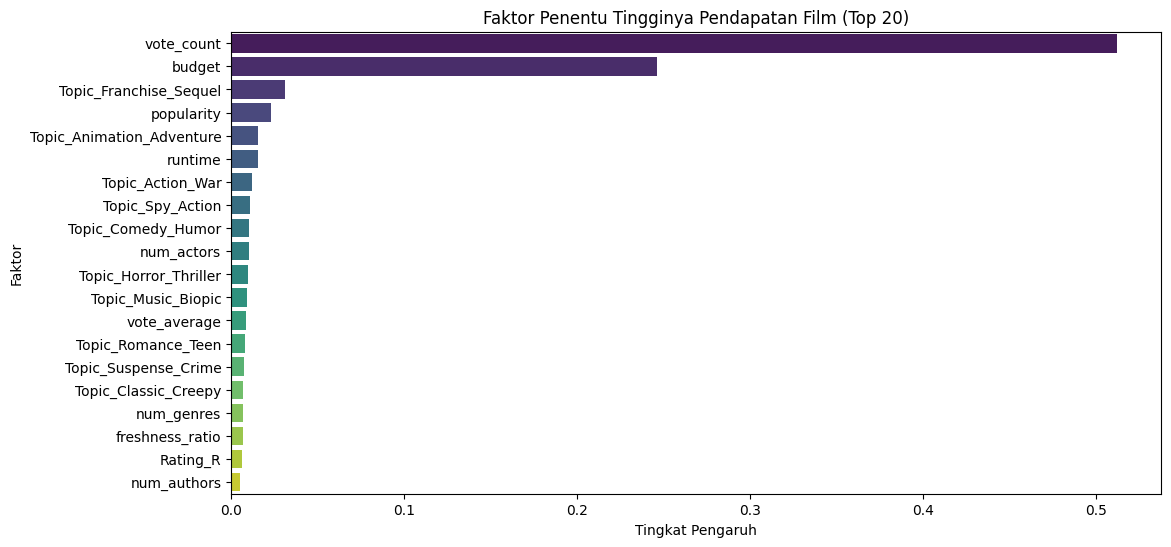


Semua Faktor Paling Berpengaruh (disortir):
                         Fitur     Score
3                   vote_count  0.511846
2                       budget  0.245935
117     Topic_Franchise_Sequel  0.031130
1                   popularity  0.022963
111  Topic_Animation_Adventure  0.015610
0                      runtime  0.015542
118           Topic_Action_War  0.011867
116           Topic_Spy_Action  0.010753
109         Topic_Comedy_Humor  0.010384
6                   num_actors  0.010119
110      Topic_Horror_Thriller  0.009705
115         Topic_Music_Biopic  0.009137
4                 vote_average  0.008462
114         Topic_Romance_Teen  0.008283
113       Topic_Suspense_Crime  0.007239
112       Topic_Classic_Creepy  0.007128
7                   num_genres  0.007039
5              freshness_ratio  0.006717
55                    Rating_R  0.006072
8                  num_authors  0.005106


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import mean_squared_error

cols_to_drop = ['movie_title', 'revenue']

X = df.drop(columns=cols_to_drop)
y = df['revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)

print(f"HASIL AKHIR (TANPA LOG TRANSFORM)")
print(f"R-Squared Score : {r2:.2f} (Akurasi Penjelasan: {r2*100:.1f}%)")
print(f"Rata-rata Meleset: ${mae:,.2f}")
print(f"Meleset: ${rmse:,.2f}")
print(f"Kuadrat Error: {mse:,.2f}")

importances = rf_model.feature_importances_
feature_names = X.columns

fi_df = pd.DataFrame({'Fitur': feature_names, 'Score': importances})
fi_df = fi_df.sort_values(by='Score', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Score', y='Fitur', data=fi_df.head(20), palette='viridis', hue='Fitur', legend=False)
plt.title('Faktor Penentu Tingginya Pendapatan Film (Top 20)')
plt.xlabel('Tingkat Pengaruh')
plt.ylabel('Faktor')
plt.show()

print("\nSemua Faktor Paling Berpengaruh (disortir):")
print(fi_df[['Fitur', 'Score']].head(20))

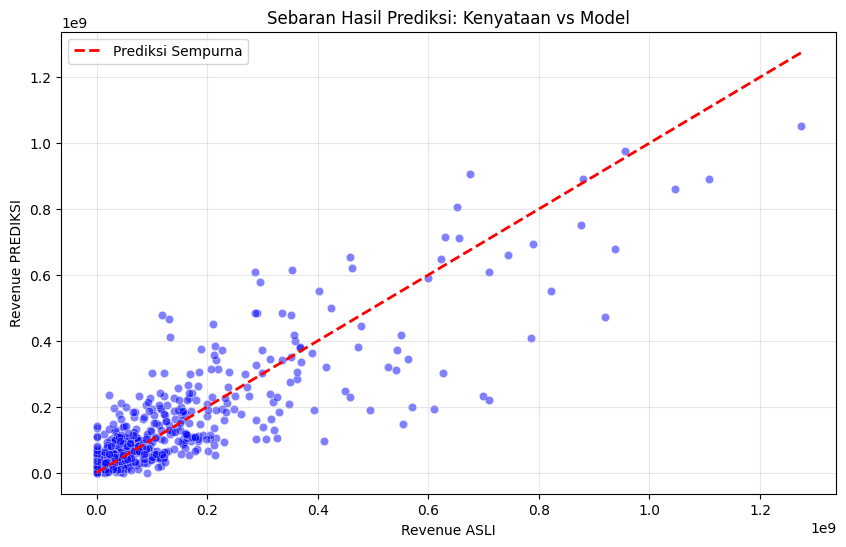

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='blue')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Prediksi Sempurna')

plt.title('Sebaran Hasil Prediksi: Kenyataan vs Model')
plt.xlabel('Revenue ASLI')
plt.ylabel('Revenue PREDIKSI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **Menggunakan Log Transformation**

HASIL AKHIR (DENGAN LOG TRANSFORM)
R-Squared Score : 0.72 (Akurasi: 72.4%)
MAE (Rata-rata Meleset) : $49,336,492.35
RMSE (Meleset): $89,682,820.07
MSE (Kuadrat Error): 8,043,008,215,297,344.00


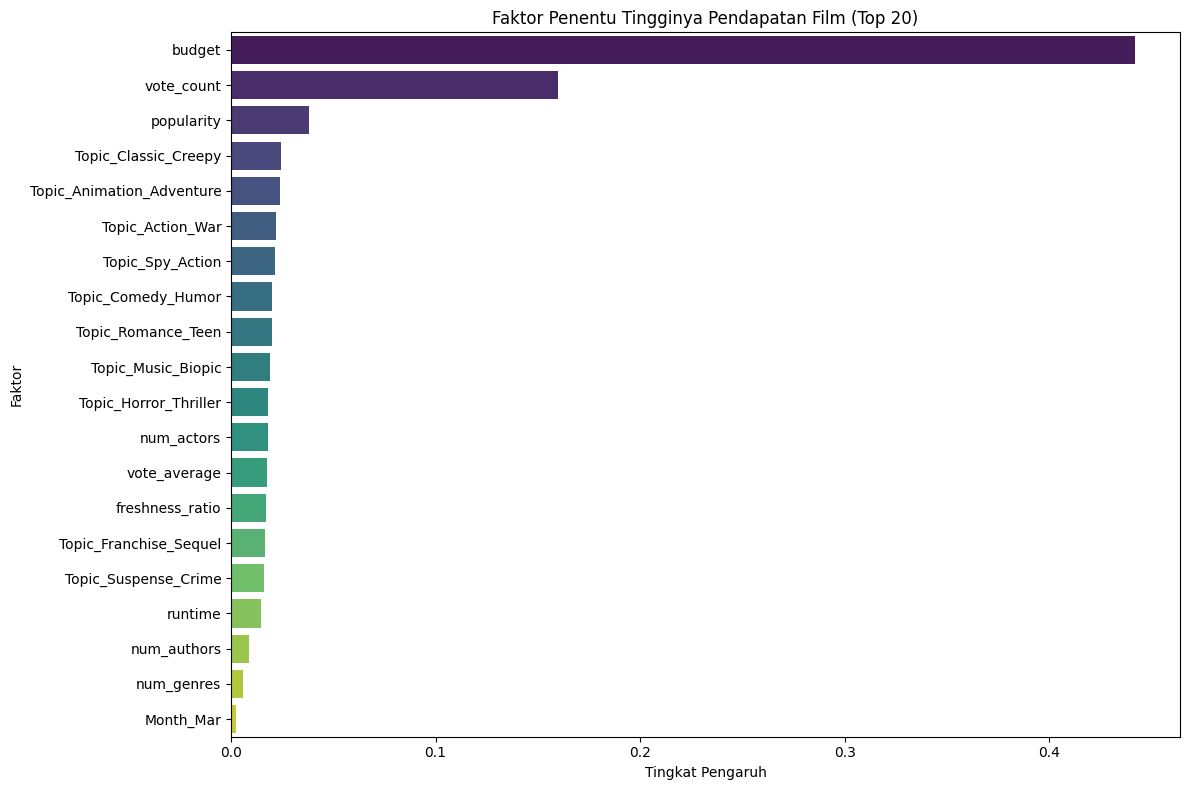


Detail Top 20 Faktor Paling Berpengaruh:
                         Fitur     Score
2                       budget  0.441741
3                   vote_count  0.159796
1                   popularity  0.037969
112       Topic_Classic_Creepy  0.024642
111  Topic_Animation_Adventure  0.023864
118           Topic_Action_War  0.022034
116           Topic_Spy_Action  0.021272
109         Topic_Comedy_Humor  0.020106
114         Topic_Romance_Teen  0.020031
115         Topic_Music_Biopic  0.019021
110      Topic_Horror_Thriller  0.018148
6                   num_actors  0.018127
4                 vote_average  0.017530
5              freshness_ratio  0.017321
117     Topic_Franchise_Sequel  0.016360
113       Topic_Suspense_Crime  0.016129
0                      runtime  0.014726
8                  num_authors  0.008811
7                   num_genres  0.005895
83                   Month_Mar  0.002454


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import mean_squared_error

df['revenue_log'] = np.log1p(df['revenue'])
cols_to_drop = ['movie_title', 'revenue', 'revenue_log']

X = df.drop(columns=cols_to_drop, errors='ignore')
X = X.select_dtypes(include=[np.number])
X = X.fillna(0)

y_log = df['revenue_log']

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_log)

y_pred_log = rf_model.predict(X_test)

y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_log)

r2 = r2_score(y_test_real, y_pred_real)
mae = mean_absolute_error(y_test_real, y_pred_real)
mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)

print(f"HASIL AKHIR (DENGAN LOG TRANSFORM)")
print(f"R-Squared Score : {r2:.2f} (Akurasi: {r2*100:.1f}%)")
print(f"MAE (Rata-rata Meleset) : ${mae:,.2f}")
print(f"RMSE (Meleset): ${rmse:,.2f}")
print(f"MSE (Kuadrat Error): {mse:,.2f}")

importances = rf_model.feature_importances_
feature_names = X.columns

fi_df = pd.DataFrame({'Fitur': feature_names, 'Score': importances})
fi_df = fi_df.sort_values(by='Score', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Score', y='Fitur', data=fi_df.head(20), palette='viridis', hue='Fitur', legend=False)
plt.title('Faktor Penentu Tingginya Pendapatan Film (Top 20)')
plt.xlabel('Tingkat Pengaruh')
plt.ylabel('Faktor')
plt.tight_layout()
plt.show()

print("\nDetail Top 20 Faktor Paling Berpengaruh:")
print(fi_df[['Fitur', 'Score']].head(20))

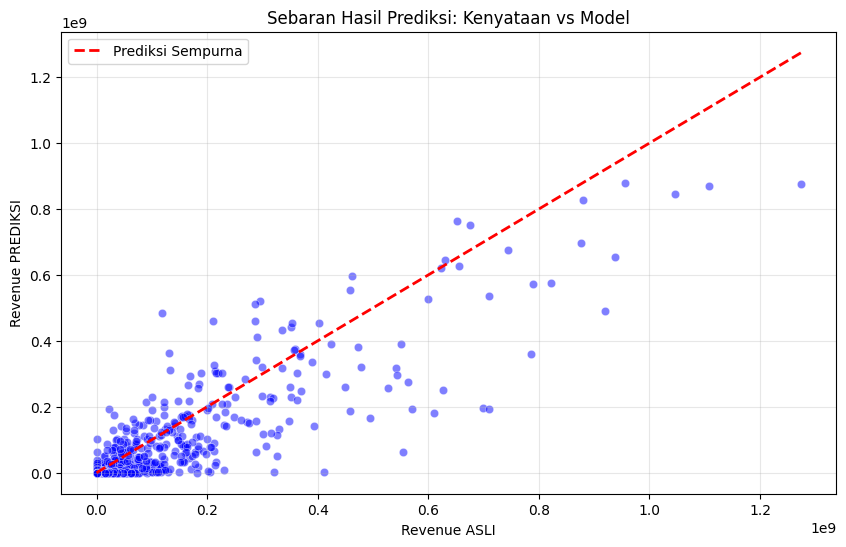

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_pred_real, alpha=0.5, color='blue')

min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Prediksi Sempurna')

plt.title('Sebaran Hasil Prediksi: Kenyataan vs Model')
plt.xlabel('Revenue ASLI')
plt.ylabel('Revenue PREDIKSI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()